In [1]:
push!(LOAD_PATH, joinpath(@__DIR__, "../../../lib/"));
using PyPlot
using NaCsPlot
using NaCsData

[ Info: Precompiling NaCsPlot [top-level]
[ Info: Disabled precompiling NaCsPlot [top-level] since the text `__precompile__(false)` was found in file.
┌ Info: Skipping precompilation due to precompilable error. Importing NaCsPlot [top-level].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.


In [2]:
const ion_param_names, ion_data = NaCsData.load_dax_scan1(joinpath(@__DIR__, "data/000139496-RamanScan.h5"))

(("detune", "duration"), NaCsData.SortedData{1, 2, @NamedTuple{detune::Float64, duration::Float64}, NaCsData.CountValues{2}}[SortedData(params=[(detune = 0.0, duration = 0.0015789473684210526), (detune = 0.0, duration = 0.0), (detune = 0.0, duration = 0.002105263157894737), (detune = 0.0, duration = 0.004736842105263157), (detune = 0.0, duration = 0.003157894736842105), (detune = 0.0, duration = 0.0002631578947368421), (detune = 0.0, duration = 0.003421052631578947), (detune = 0.0, duration = 0.0018421052631578947), (detune = 0.0, duration = 0.004210526315789474), (detune = 0.0, duration = 0.002631578947368421), (detune = 0.0, duration = 0.0023684210526315787), (detune = 0.0, duration = 0.0010526315789473684), (detune = 0.0, duration = 0.0007894736842105263), (detune = 0.0, duration = 0.0044736842105263155), (detune = 0.0, duration = 0.0028947368421052633), (detune = 0.0, duration = 0.0005263157894736842), (detune = 0.0, duration = 0.003947368421052632), (detune = 0.0, duration = 0.005

In [3]:
const ion_wait_data = NaCsData.map_params((_, p)->p.duration, ion_data[1])

SortedData(params=[0.0015789473684210526, 0.0, 0.002105263157894737, 0.004736842105263157, 0.003157894736842105, 0.0002631578947368421, 0.003421052631578947, 0.0018421052631578947, 0.004210526315789474, 0.002631578947368421, 0.0023684210526315787, 0.0010526315789473684, 0.0007894736842105263, 0.0044736842105263155, 0.0028947368421052633, 0.0005263157894736842, 0.003947368421052632, 0.005, 0.0036842105263157894, 0.0013157894736842105], data=NaCsCalc.Format.Unc{Float64}[9.9(73)e-3; 3.3(33)e-3; … ; 2.3(11)e-2; 9.9(73)e-3;;])

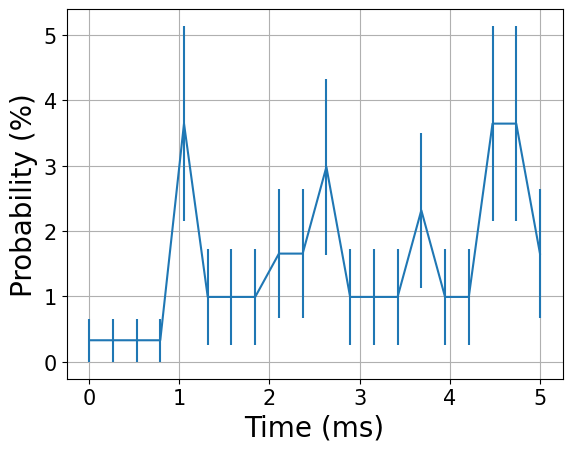

In [4]:
NaCsPlot.plot_loading_data(ion_wait_data, 100, xscale=1000)
xlabel("Time (ms)")
ylabel("Probability (%)")
grid()

In [5]:
include("sampler.jl");

In [6]:
function get_data(data, step, avg)
    if step == 1
        return Float64.(data)
    end
    if !avg
        return Float64.(@view(data[1:step:end]))
    end
    len = length(data)
    idxs = 1:step:len
    new_len = length(idxs)
    res = Vector{Float64}(undef, new_len)
    @inbounds for i in 1:new_len
        old_starti = idxs[i]
        old_endi = min(old_starti + step - 1, len)
        v = 0.0
        for old_i in old_starti:old_endi
            v += data[old_i]
        end
        res[i] = v / (old_endi - old_starti + 1)
    end
    return res
end

function sample_rabi_waveform(waveforms, tlen, num, flip, tπ; offset=0, tscale=1, yscale=1, step=1, average_step=false)
    dt = waveforms[1].meta["XIncrement"] * step
    datas = [get_data(wf.data[1], step, average_step) for wf in waveforms]
    avg = average_data(datas; offset=offset)
    len = ceil(Int, tlen / dt) + 1
    return (dt * tscale) * (0:len - 1), sample_rabi(datas, len, num, flip, π * dt / avg / tπ; offset=offset, yscale=yscale)
end

sample_rabi_waveform (generic function with 1 method)

In [7]:
const data_dc_200us = [NaCsData.Agilent.load_bin("data/dc 200us$(i).bin")[1] for i in 0:3];
const data_dc_10ms = [NaCsData.Agilent.load_bin("data/dc 10ms$(i).bin")[1] for i in 0:3];
const data_dc_500ms = [NaCsData.Agilent.load_bin("data/dc 500ms$(i).bin")[1] for i in 0:3];

In [8]:
const data_aom_200us = [NaCsData.Agilent.load_bin("data/aom dc 200us$(i).bin")[1] for i in 0:5];
const data_aom_2ms = [NaCsData.Agilent.load_bin("data/aom dc 2ms$(i).bin")[1] for i in 0:10];
const data_aom_50ms =
[NaCsData.Agilent.load_bin("data/aom dc 50ms$(i).bin")[1] for i in 0:9];
const data_aom_500ms = [NaCsData.Agilent.load_bin("data/aom dc 500ms$(i).bin")[1] for i in 0:5];

In [9]:
const data_aom_ac_2ms = [NaCsData.Agilent.load_bin("data/aom ac 2ms$(i).bin")[1] for i in 0:7];
const data_aom_ac_50ms = [NaCsData.Agilent.load_bin("data/aom ac 50ms$(i).bin")[1] for i in 0:7];

In [10]:
const data_aom_ff_200us = [NaCsData.Agilent.load_bin("data/aom ff dc 200us$(i).bin")[1] for i in 0:4];
const data_aom_ff_2ms = [NaCsData.Agilent.load_bin("data/aom ff dc 2ms$(i).bin")[1] for i in 0:8];
const data_aom_ff_2ms = [NaCsData.Agilent.load_bin("data/aom ff dc 20ms$(i).bin")[1] for i in 0:1];
const data_aom_ff_50ms = [NaCsData.Agilent.load_bin("data/aom ff dc 50ms$(i).bin")[1] for i in 0:7];
const data_aom_ff_500ms = [NaCsData.Agilent.load_bin("data/aom ff dc 500ms$(i).bin")[1] for i in 0:4];

In [11]:
const data_aom_cur_ac_200us = [NaCsData.Agilent.load_bin("data/aom current ac 200us$(i).bin")[1] for i in 0:4];
const data_aom_cur_ac_2ms = [NaCsData.Agilent.load_bin("data/aom current ac 2ms$(i).bin")[1] for i in 0:9];
const data_aom_cur_ac_50ms = [NaCsData.Agilent.load_bin("data/aom current ac 50ms$(i).bin")[1] for i in 0:9];

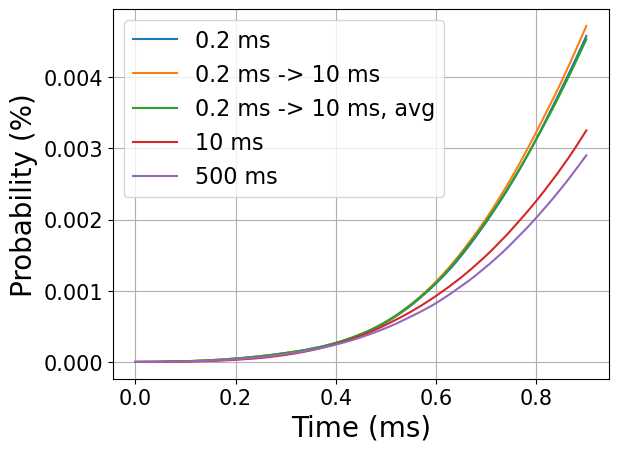

In [12]:
plot(sample_rabi_waveform(data_dc_200us, 900e-6, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="0.2 ms")
plot(sample_rabi_waveform(data_dc_200us, 900e-6, 2000, 1, 171e-6; tscale=1000, yscale=100, step=50)..., label="0.2 ms -> 10 ms")
plot(sample_rabi_waveform(data_dc_200us, 900e-6, 2000, 1, 171e-6; tscale=1000, yscale=100, step=50, average_step=true)..., label="0.2 ms -> 10 ms, avg")
plot(sample_rabi_waveform(data_dc_10ms, 900e-6, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="10 ms")
plot(sample_rabi_waveform(data_dc_500ms, 900e-6, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="500 ms")
legend(fontsize=16)
xlabel("Time (ms)")
ylabel("Probability (%)")
grid()
NaCsPlot.save("imgs/dc_resolution_compare_20260113", close=false)

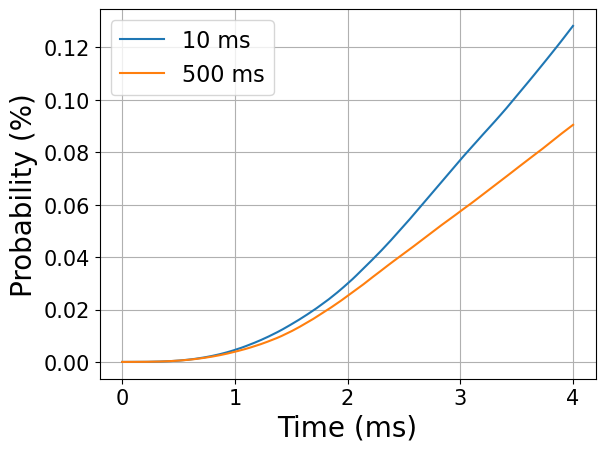

In [13]:
plot(sample_rabi_waveform(data_dc_10ms, 4e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="10 ms")
plot(sample_rabi_waveform(data_dc_500ms, 4e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="500 ms")
legend(fontsize=16)
xlabel("Time (ms)")
ylabel("Probability (%)")
grid()
NaCsPlot.save("imgs/dc_resolution_compare_long_20260113", close=false)

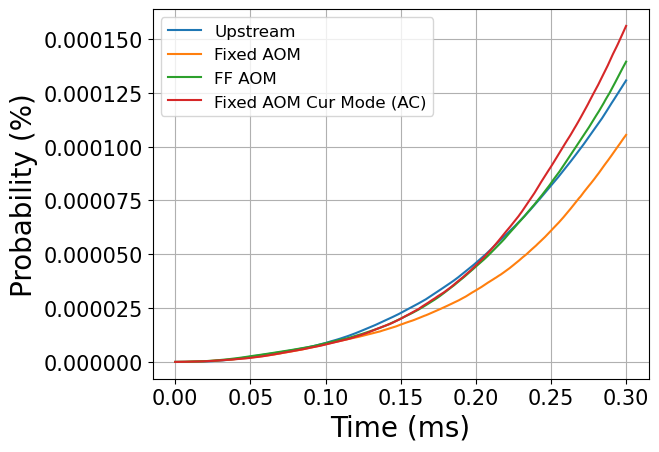

In [14]:
plot(sample_rabi_waveform(data_dc_200us, 0.3e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="Upstream")
plot(sample_rabi_waveform(data_aom_200us, 0.3e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="Fixed AOM")
plot(sample_rabi_waveform(data_aom_ff_200us, 0.3e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="FF AOM")
plot(sample_rabi_waveform(data_aom_cur_ac_200us, 0.3e-3, 2000, 1, 171e-6; offset=3.2, tscale=1000, yscale=100)..., label="Fixed AOM Cur Mode (AC)")
legend(fontsize=12)
xlabel("Time (ms)")
ylabel("Probability (%)")
grid()
NaCsPlot.save("imgs/condition_compare_20260113", close=false)

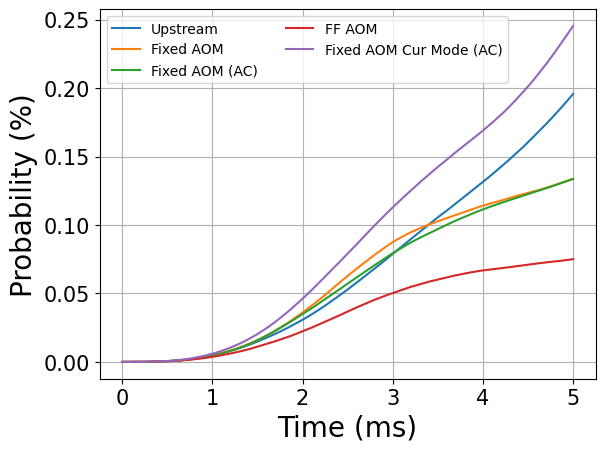

In [15]:
plot(sample_rabi_waveform(data_dc_10ms, 5e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="Upstream")
plot(sample_rabi_waveform(data_aom_50ms, 5e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="Fixed AOM")
plot(sample_rabi_waveform(data_aom_ac_50ms, 5e-3, 2000, 1, 171e-6; offset=4, tscale=1000, yscale=100)..., label="Fixed AOM (AC)")
plot(sample_rabi_waveform(data_aom_ff_50ms, 5e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="FF AOM")
plot(sample_rabi_waveform(data_aom_cur_ac_50ms, 5e-3, 2000, 1, 171e-6; offset=3.2, tscale=1000, yscale=100)..., label="Fixed AOM Cur Mode (AC)")
legend(ncol=2, fontsize=10)
xlabel("Time (ms)")
ylabel("Probability (%)")
grid()
NaCsPlot.save("imgs/condition_compare_long_20260113", close=false)

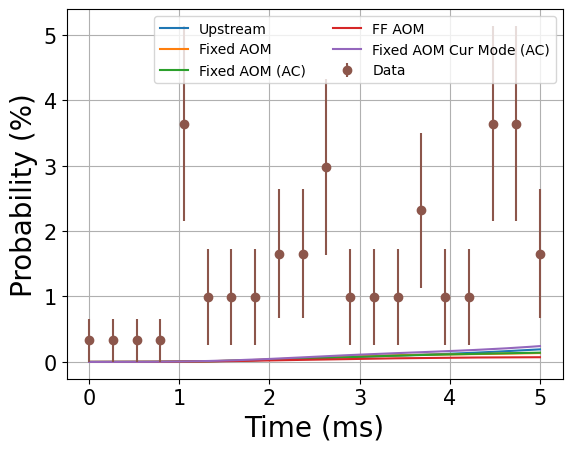

In [16]:
plot(sample_rabi_waveform(data_dc_10ms, 5e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="Upstream")
plot(sample_rabi_waveform(data_aom_50ms, 5e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="Fixed AOM")
plot(sample_rabi_waveform(data_aom_ac_50ms, 5e-3, 2000, 1, 171e-6; offset=4, tscale=1000, yscale=100)..., label="Fixed AOM (AC)")
plot(sample_rabi_waveform(data_aom_ff_50ms, 5e-3, 2000, 1, 171e-6; tscale=1000, yscale=100)..., label="FF AOM")
plot(sample_rabi_waveform(data_aom_cur_ac_50ms, 5e-3, 2000, 1, 171e-6; offset=3.2, tscale=1000, yscale=100)..., label="Fixed AOM Cur Mode (AC)")
NaCsPlot.plot_loading_data(ion_wait_data, 100, xscale=1000, fmt="o", label="Data")
legend(ncol=2, fontsize=10)
xlabel("Time (ms)")
ylabel("Probability (%)")
grid()
NaCsPlot.save("imgs/experiment_compare_20260113", close=false)